# 04 Deep Learning

A bridge from scikit-learn to PyTorch before the mechanism studies of Notebooks 05–06: train a small MLP on the easiest real split in this repo — rank 0 vs rank 2 — and ask whether depth buys anything over the logistic-regression baseline.

**MPS notes:** tensors are cast to float32 (MPS has no float64); `pin_memory` is left off (CUDA-only).

In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from murmurations import ml
from murmurations import torch_models as tm
from murmurations.features import hasse_matrix

DATA = Path("..") / "data"
ec_7500_10000 = pd.read_parquet(DATA / "ec_7500_10000_r012_1000ap.parquet")

In [2]:
device = tm.get_device()
print("device:", device)  # 'mps' with Apple Silicon

device: mps


### Prepare tensors — rank 0 vs rank 2

In [3]:
# Balance down to the scarce class (771 rank-2 curves): accuracy is then
# interpretable against a 0.5 base rate, and directly comparable with
# ml.logistic_experiment, which balances the same way.
rng = np.random.default_rng(0)
r0 = ec_7500_10000[ec_7500_10000["rank"] == 0]
r2 = ec_7500_10000[ec_7500_10000["rank"] == 2]
sub = pd.concat(
    [ec_7500_10000.loc[rng.choice(r0.index, size=len(r2), replace=False)], r2]
)

# Hasse normalization (a_p / 2 sqrt p) uses fixed per-prime constants --
# nothing is fitted to the data, so the internal train/val split in
# make_loaders cannot leak preprocessing statistics.
X = hasse_matrix(sub, num_primes=1000)
y = (sub["rank"].to_numpy() == 2).astype("int64")
train_loader, val_loader = tm.make_loaders(
    X, y, batch_size=256, device=device, seed=0
)

### Model + training

In [4]:
model = tm.MLP(in_dim=X.shape[1], n_classes=2, hidden=(256, 128))
history = tm.train(model, train_loader, val_loader, device, epochs=40, lr=1e-3)

epoch   1  train 0.6592  val 0.6497  acc 0.8344
epoch   5  train 0.0260  val 0.1352  acc 0.9773
epoch  10  train 0.0055  val 0.0621  acc 0.9903
epoch  15  train 0.0028  val 0.0524  acc 0.9935
epoch  20  train 0.0021  val 0.0471  acc 0.9935
epoch  25  train 0.0016  val 0.0435  acc 0.9935
epoch  30  train 0.0012  val 0.0413  acc 0.9935
epoch  35  train 0.0011  val 0.0392  acc 0.9935
epoch  40  train 0.0009  val 0.0380  acc 0.9935


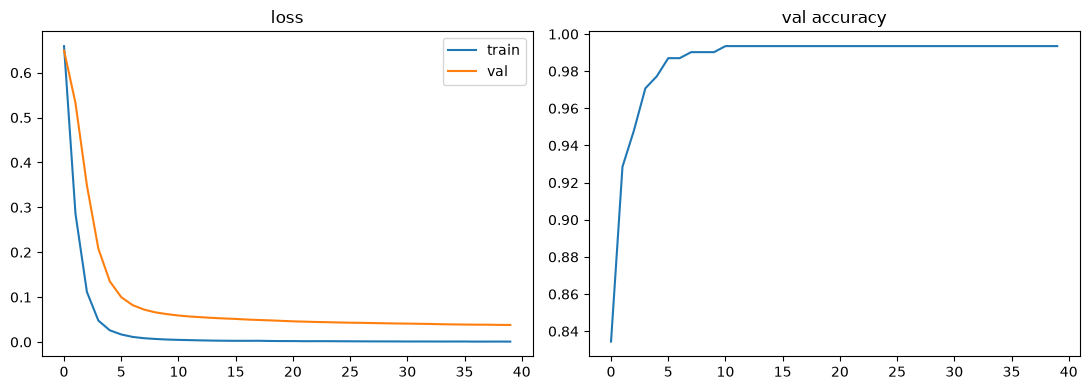

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history.train_loss, label="train")
ax[0].plot(history.val_loss, label="val")
ax[0].set_title("loss")
ax[0].legend()
ax[1].plot(history.val_acc)
ax[1].set_title("val accuracy")
plt.tight_layout()
plt.show()

### Compare against the linear baseline
Does depth buy anything over logistic regression on these features?

In [6]:
lin = ml.logistic_experiment(
    ec_7500_10000, ranks=[0, 2], n_features=1000, seed=0
)
print(f"logistic regression: {lin.accuracy:.3f}")
print(f"MLP (best val):      {max(history.val_acc):.3f}")

logistic regression: 0.992
MLP (best val):      0.994


Depth buys essentially nothing: 0.994 vs 0.992 is a gap of one or two curves on a ~300-row validation set — and the MLP figure is a best-epoch selection while the logistic figure is a single held-out test, so even that sliver is generous to the MLP. As Notebook 05 shows, the rank signal here is a class-mean shift, which is exactly what a linear model reads. The MLP's job in this repo is done: the stack works, and the interesting architectural question — sequence structure — belongs to the CNN in Notebook 06.

### Where this goes next

- **Notebook 05** asks *which* signal the models are reading (mean vs skew), using a synthetic testbed with ground truth.
- **Notebook 06** gives the deep model its real chance: a 1-D CNN over the prime sequence, with a shuffle control to isolate what the architecture contributes.

Untried extensions: a ternary head (ranks 0/1/2 — `n_classes=3` with raw rank labels), and predicting the root number directly (cf. A. Pozdnyakov, [*Predicting Root Numbers with Neural Networks*](https://arxiv.org/abs/2403.14631))